In [1]:
from src.ColorsAnalysis import *
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
plt.style.use('properties.mplstyle')

In [2]:
savepath = "../results/ColorAnalysis/3D"
create_folder(savepath)

Folder created: ../results/ColorAnalysis/3D


## 3D

In [3]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 3

# 1) Ler convertendo "Null" para NaN
df = pd.read_csv(f"../Data/{type_perc}_percolation/nc_dim_{dim}.csv")
df

,L,n_colors,NT,n_c,n_c_err,rho,k,Nsamples
0,128,2,1600,2.0,0.0,0.000100,0.000010,1000
1,128,2,1600,2.0,0.0,0.006428,0.000010,1000
2,128,2,1600,2.0,0.0,0.012756,0.000010,1000
3,128,2,1600,2.0,0.0,0.019084,0.000010,1000
4,128,2,1600,2.0,0.0,0.025411,0.000010,1000
...,...,...,...,...,...,...,...,...
476,256,8,6500,0.0,0.0,0.118680,0.000003,500
477,256,8,6500,0.0,0.0,0.120260,0.000003,500
478,256,8,6500,0.0,0.0,0.121840,0.000003,500
479,256,8,6500,0.0,0.0,0.123420,0.000003,500


## 4 COLORS

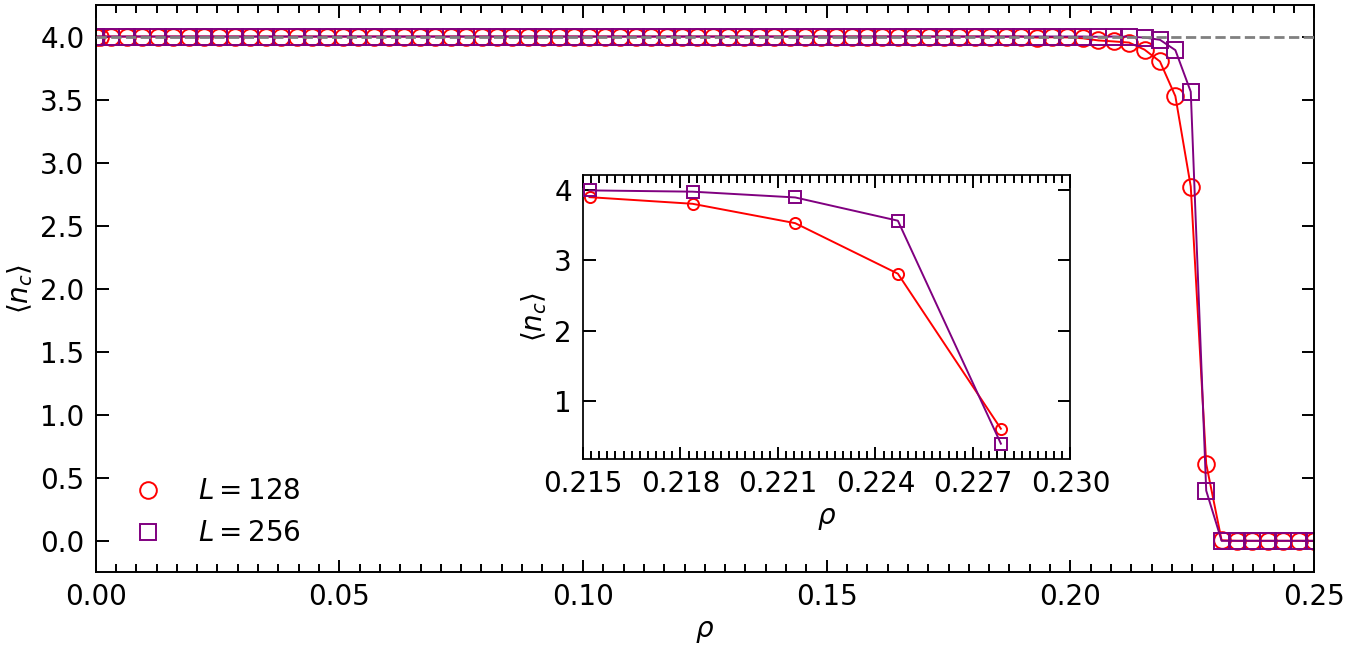

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, MaxNLocator
from matplotlib.lines import Line2D

# -------- parâmetros do plot --------
num_colors_fix = 4          # <<< num_colors fixo
L_values       = [128, 256] # <<< tamanhos a comparar
k_values       = [1.0e-05, 3.0e-06]   # ou: None

ms = 12
font_tick_size = 20
font_label_size = 20
font_legend_size = 20
colors  = ["red", "purple", "green", "blue"]
markers = ["o-", "s-", "d-", "^-"]
mew = 1.4
thickness = 1.4

# -------- helper: média de n_c por rho, com filtros --------
def mean_nc_by_rho_new(df: pd.DataFrame, n_colors: int, L: int, k: float | None = None):
    m = (df["n_colors"] == n_colors) & (df["L"] == L)
    if k is not None:
        m &= np.isclose(df["k"], k)

    df_f = df.loc[m, ["rho", "n_c"]]
    if df_f.empty:
        return pd.DataFrame(columns=["rho", "nc_mean", "nc_err"])

    g = (df_f.groupby("rho", as_index=False)
               .agg(nc_mean=("n_c", "mean"),
                    nc_std =("n_c", "std"),
                    count  =("n_c", "size")))
    g["nc_err"] = g["nc_std"] / np.sqrt(g["count"].clip(lower=1))
    return g[["rho", "nc_mean", "nc_err"]].sort_values("rho")

# ===== Figura e eixo principais =====
fig, ax = plt.subplots(figsize=(14, 7))
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))

datasets = []
legend_handles = []

# garantir iteráveis pareados de L e k (ou k=None)
if isinstance(k_values, list) and len(k_values) == len(L_values):
    LK_iter = zip(L_values, k_values)
else:
    LK_iter = [(L, None) for L in L_values]

for idx, (L, kval) in enumerate(LK_iter):
    res = mean_nc_by_rho_new(df, n_colors=num_colors_fix, L=L, k=kval)
    if res.empty:
        continue

    fmt   = markers[idx % len(markers)]
    color = colors [idx % len(colors)]

    line = ax.plot(res["rho"], res["nc_mean"], fmt,
                   color=color, linewidth=thickness,
                   ms=ms, markeredgewidth=mew, zorder=2)[0]

    datasets.append((res["rho"].to_numpy(),
                     res["nc_mean"].to_numpy(),
                     line.get_marker(), color))

    legend_handles.append(Line2D(
        [], [], linestyle='None',
        marker=line.get_marker(), markersize=ms,
        markeredgewidth=mew, markerfacecolor='none',
        markeredgecolor=color, color=color,
        label=fr"$L = {L}$"
    ))

# ----- Inset (zoom) -----
x0, x1 = 0.215, 0.230
inset_x, inset_y, inset_w, inset_h = 0.40, 0.20, 0.40, 0.50
axins = ax.inset_axes([inset_x, inset_y, inset_w, inset_h], zorder=10)

axins.set_facecolor("white")
axins.grid(False)

ys_zoom = []
for (x, y, marker, color) in datasets:
    m = (x >= x0) & (x <= x1)
    if np.any(m):
        axins.plot(x[m], y[m], linestyle='-',
                   marker=marker, color=color,
                   linewidth=thickness, ms=max(6, int(ms*0.7)),
                   markeredgewidth=mew, markerfacecolor='none', zorder=11)
        ys_zoom.append(y[m])

axins.set_xlim(x0, x1)
if ys_zoom:
    y_all = np.concatenate(ys_zoom)
    pad = 0.06 * (np.ptp(y_all) if np.ptp(y_all) > 0 else 1.0)
    axins.set_ylim(y_all.min() - pad, y_all.max() + pad)

axins.set_xlim(x0, x1)

# Configurando os ticks principais e menores para o eixo X do inset
major_locator = np.linspace(x0, x1, 6)  # 6 ticks principais igualmente espaçados entre x0 e x1
minor_locator = np.linspace(x0, x1, 61)  # 10 divisões menores dentro de cada tick principal

axins.set_xticks(major_locator)
axins.set_xticks(minor_locator, minor=True)

# Rótulos no eixo x para mostrar 0 e 1/num_colors fixo, com precisão ajustada
axins.set_xticklabels([f"{tick:.3f}" for tick in major_locator])

# Configuração dos ticks
axins.tick_params(axis='both', which='major', labelsize=int(font_tick_size), length=9, width=thickness)
axins.tick_params(axis='x',   which='minor', length=6, width=thickness)

axins.set_xlabel(r"$\rho$")
axins.set_ylabel(r"$\langle n_c \rangle $")
for s in axins.spines.values():
    s.set_linewidth(thickness*0.9)

# ----- eixo principal -----
ax.axhline(y=num_colors_fix, color='gray', linestyle='--', lw=2.0, zorder=100)
ax.set_xlabel(r"$\rho$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, num_colors_fix + 0.25])

# Limite físico do eixo x: 0 ≤ rho ≤ 1/num_colors
ax.set_xlim(0.0, 1.0/num_colors_fix)

# Configurando os ticks principais e menores para o eixo X
major_locator = np.linspace(0.0, 1.0/num_colors_fix, 6)
minor_locator = np.linspace(0.0, 1.0/num_colors_fix, 61)

ax.set_xticks(major_locator)
ax.set_xticks(minor_locator, minor=True)

# Rótulos no eixo x para mostrar 0 e 1/num_colors fixo
ax.set_xticklabels([f"{tick:.2f}" for tick in major_locator])

# Personalizando os ticks
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)

ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="lower left", frameon=False)

plt.tight_layout()
plt.show()


## 8 COLORS

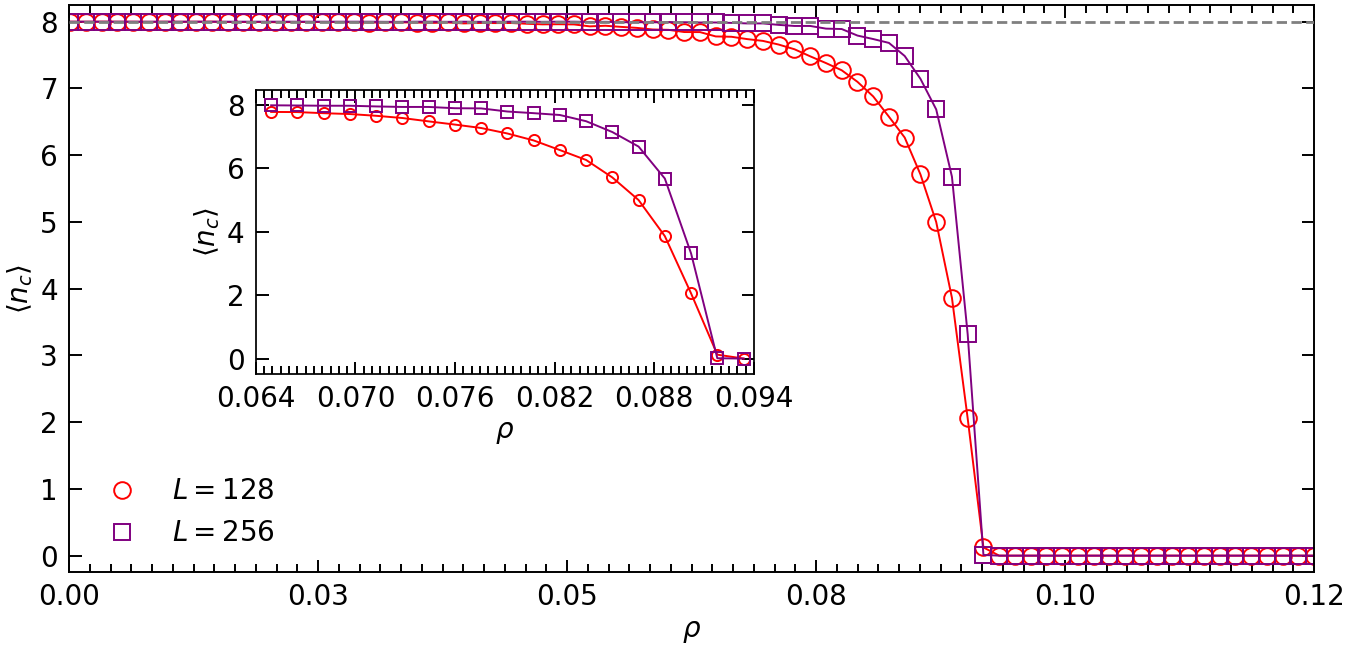

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, MaxNLocator
from matplotlib.lines import Line2D

# -------- parâmetros do plot --------
num_colors_fix = 8          # <<< num_colors fixo
L_values       = [128, 256] # <<< tamanhos a comparar
k_values       = [1.0e-05, 3.0e-06]   # ou: None

ms = 12
font_tick_size = 20
font_label_size = 20
font_legend_size = 20
colors  = ["red", "purple", "green", "blue"]
markers = ["o-", "s-", "d-", "^-"]
mew = 1.4
thickness = 1.4

# -------- helper: média de n_c por rho, com filtros --------
def mean_nc_by_rho_new(df: pd.DataFrame, n_colors: int, L: int, k: float | None = None):
    m = (df["n_colors"] == n_colors) & (df["L"] == L)
    if k is not None:
        m &= np.isclose(df["k"], k)

    df_f = df.loc[m, ["rho", "n_c"]]
    if df_f.empty:
        return pd.DataFrame(columns=["rho", "nc_mean", "nc_err"])

    g = (df_f.groupby("rho", as_index=False)
               .agg(nc_mean=("n_c", "mean"),
                    nc_std =("n_c", "std"),
                    count  =("n_c", "size")))
    g["nc_err"] = g["nc_std"] / np.sqrt(g["count"].clip(lower=1))
    return g[["rho", "nc_mean", "nc_err"]].sort_values("rho")

# ===== Figura e eixo principais =====
fig, ax = plt.subplots(figsize=(14, 7))
ax.yaxis.set_major_locator(MultipleLocator(1.0))
#ax.yaxis.set_minor_locator(MultipleLocator(0.5))

datasets = []
legend_handles = []

# garantir iteráveis pareados de L e k (ou k=None)
if isinstance(k_values, list) and len(k_values) == len(L_values):
    LK_iter = zip(L_values, k_values)
else:
    LK_iter = [(L, None) for L in L_values]

for idx, (L, kval) in enumerate(LK_iter):
    res = mean_nc_by_rho_new(df, n_colors=num_colors_fix, L=L, k=kval)
    if res.empty:
        continue

    fmt   = markers[idx % len(markers)]
    color = colors [idx % len(colors)]

    line = ax.plot(res["rho"], res["nc_mean"], fmt,
                   color=color, linewidth=thickness,
                   ms=ms, markeredgewidth=mew, zorder=2)[0]

    datasets.append((res["rho"].to_numpy(),
                     res["nc_mean"].to_numpy(),
                     line.get_marker(), color))

    legend_handles.append(Line2D(
        [], [], linestyle='None',
        marker=line.get_marker(), markersize=ms,
        markeredgewidth=mew, markerfacecolor='none',
        markeredgecolor=color, color=color,
        label=fr"$L = {L}$"
    ))

# ----- Inset (zoom) -----
x0, x1 = 0.064, 0.094
inset_x, inset_y, inset_w, inset_h = 0.15, 0.35, 0.40, 0.50
axins = ax.inset_axes([inset_x, inset_y, inset_w, inset_h], zorder=10)

axins.set_facecolor("white")
axins.grid(False)

ys_zoom = []
for (x, y, marker, color) in datasets:
    m = (x >= x0) & (x <= x1)
    if np.any(m):
        axins.plot(x[m], y[m], linestyle='-',
                   marker=marker, color=color,
                   linewidth=thickness, ms=max(6, int(ms*0.7)),
                   markeredgewidth=mew, markerfacecolor='none', zorder=11)
        ys_zoom.append(y[m])


if ys_zoom:
    y_all = np.concatenate(ys_zoom)
    pad = 0.06 * (np.ptp(y_all) if np.ptp(y_all) > 0 else 1.0)
    axins.set_ylim(y_all.min() - pad, y_all.max() + pad)

axins.set_xlim(x0, x1)

# Configurando os ticks principais e menores para o eixo X do inset
major_locator = np.linspace(x0, x1, 6)  # 6 ticks principais igualmente espaçados entre x0 e x1
minor_locator = np.linspace(x0, x1, 61)  # 10 divisões menores dentro de cada tick principal

axins.set_xticks(major_locator)
axins.set_xticks(minor_locator, minor=True)

# Rótulos no eixo x para mostrar 0 e 1/num_colors fixo, com precisão ajustada
axins.set_xticklabels([f"{tick:.3f}" for tick in major_locator])

# Configuração dos ticks
axins.tick_params(axis='both', which='major', labelsize=int(font_tick_size), length=9, width=thickness)
axins.tick_params(axis='x',   which='minor', length=6, width=thickness)

#axins.tick_params(axis='y',   which='minor', length=6, width=thickness)

axins.set_xlabel(r"$\rho$")
axins.set_ylabel(r"$\langle n_c \rangle $")
for s in axins.spines.values():
    s.set_linewidth(thickness*0.9)

# ----- eixo principal -----
ax.axhline(y=num_colors_fix, color='gray', linestyle='--', lw=2.0, zorder=100)
ax.set_xlabel(r"$\rho$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, num_colors_fix + 0.25])

# Limite físico do eixo x: 0 ≤ rho ≤ 1/num_colors
ax.set_xlim(0.0, 1.0/num_colors_fix)

# Configurando os ticks principais e menores para o eixo X
major_locator = np.linspace(0.0, 1.0/num_colors_fix, 6)
minor_locator = np.linspace(0.0, 1.0/num_colors_fix, 61)

ax.set_xticks(major_locator)
ax.set_xticks(minor_locator, minor=True)

# Rótulos no eixo x para mostrar 0 e 1/num_colors fixo
ax.set_xticklabels([f"{tick:.2f}" for tick in major_locator])

# Personalizando os ticks
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)

ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="lower left", frameon=False)

plt.tight_layout()
plt.show()


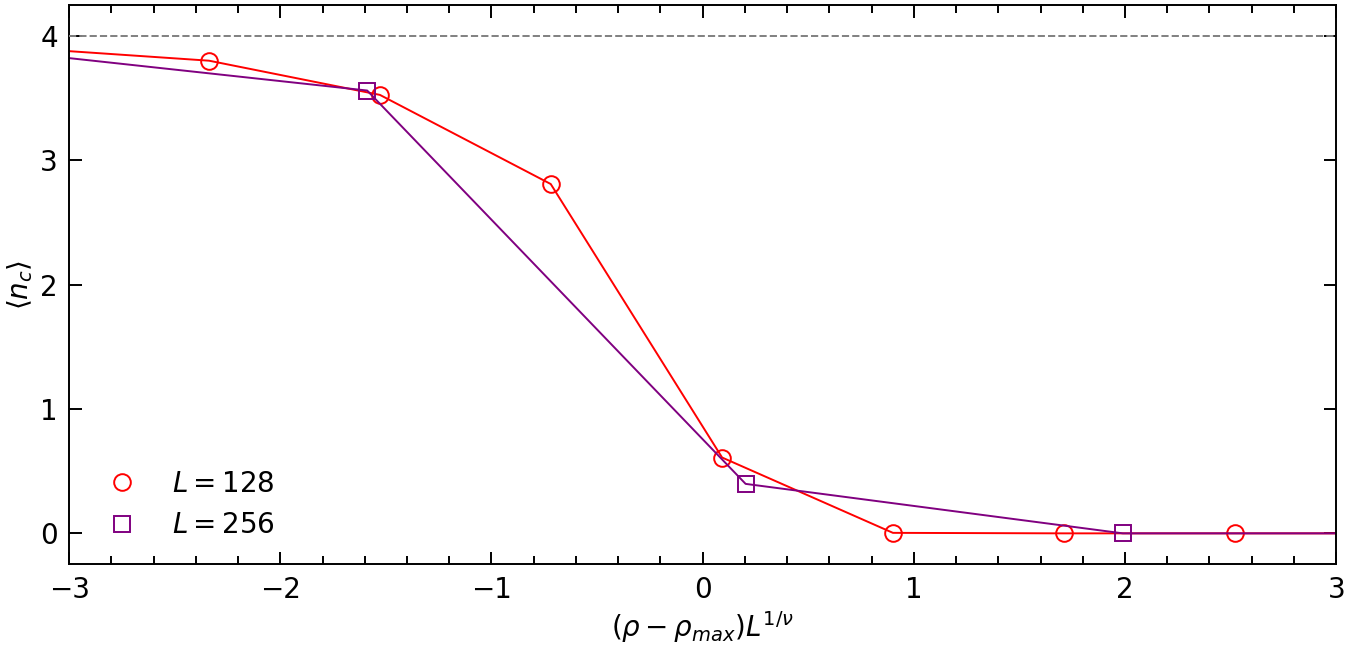

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from matplotlib.lines import Line2D

# Parâmetros do gráfico
p0_filter = 1.0
num_colors_fix = 4          # <<< num_colors fixo
L_values       = [128, 256] # <<< tamanhos a comparar
k_values       = [1.0e-05, 3.0e-06]   # ou: None
rho_max = 0.2275
ms = 12
font_tick_size = 20
font_label_size = 20
font_legend_size = 20
colors = ["red", "purple", "green", "blue"]
markers = ["o-", "s-", "d-", "^-"]   # formatos do PLOT (linha + marcador)
mew = 1.4
thickness = 1.4

assert len(L_values) == len(k_values), "L_values e k_values devem ter o mesmo tamanho."

# Criando a figura e o eixo
fig, ax = plt.subplots(figsize=(14, 7))
legend_handles = []

# Loop para os valores de L e k
for idx, (L, kval) in enumerate(zip(L_values, k_values)):
    # Filtrando os dados diretamente com L e k
    df_filtered = df[(df["L"] == L) & (np.isclose(df["k"], kval)) & (df["n_colors"]==num_colors_fix)]

    if df_filtered.empty:
        print(f"[WARN] sem dados para L={L}, k={kval}")
        continue

    fmt = markers[idx % len(markers)]
    color = colors[idx % len(colors)]

    # Reescalando e plotando os dados diretamente do dataframe
    res_scaled = (df_filtered["rho"] - rho_max) * L ** (1 / 0.875)
    line, = ax.plot(res_scaled, df_filtered["n_c"], fmt,
                    color=color, linewidth=thickness,
                    ms=ms, markeredgewidth=mew, zorder=2)

    # Handle da legenda com o mesmo estilo do marcador
    handle = Line2D(
        [0], [0],
        linestyle='None',
        marker=line.get_marker(),
        markersize=ms,
        markeredgewidth=line.get_markeredgewidth(),
        markeredgecolor=line.get_markeredgecolor(),
        markerfacecolor=line.get_markerfacecolor(),      # pode ser 'none' — mantemos
        fillstyle=line.get_fillstyle(),
        alpha=(line.get_alpha() if line.get_alpha() is not None else 1.0),
        color=line.get_color(),
        label=fr"$L = {L}$",
    )
    legend_handles.append(handle)

# Definir os limites e a linha guia
ax.set_xlim([-3, 3])  # Ajuste no limite de X após reescalamento
ax.axhline(y=4, xmin=0.0, xmax=1.0, color='gray', linestyle='--', lw=1.4, zorder=100)

# Definir rótulos e limites no gráfico
ax.set_xlabel(r"$(\rho - \rho_{max})L^{1/\nu}$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, 4.25])

# Definir ticks no eixo X e Y
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_major_locator(MultipleLocator(1.0))

# Ajustar parâmetros dos ticks
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)

# Aumentar a espessura das bordas do gráfico
for spine in ax.spines.values():
    spine.set_linewidth(thickness)

# Legenda com os handles personalizados
ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="lower left")

# Ajuste final de layout e exibição
plt.tight_layout()
plt.show()


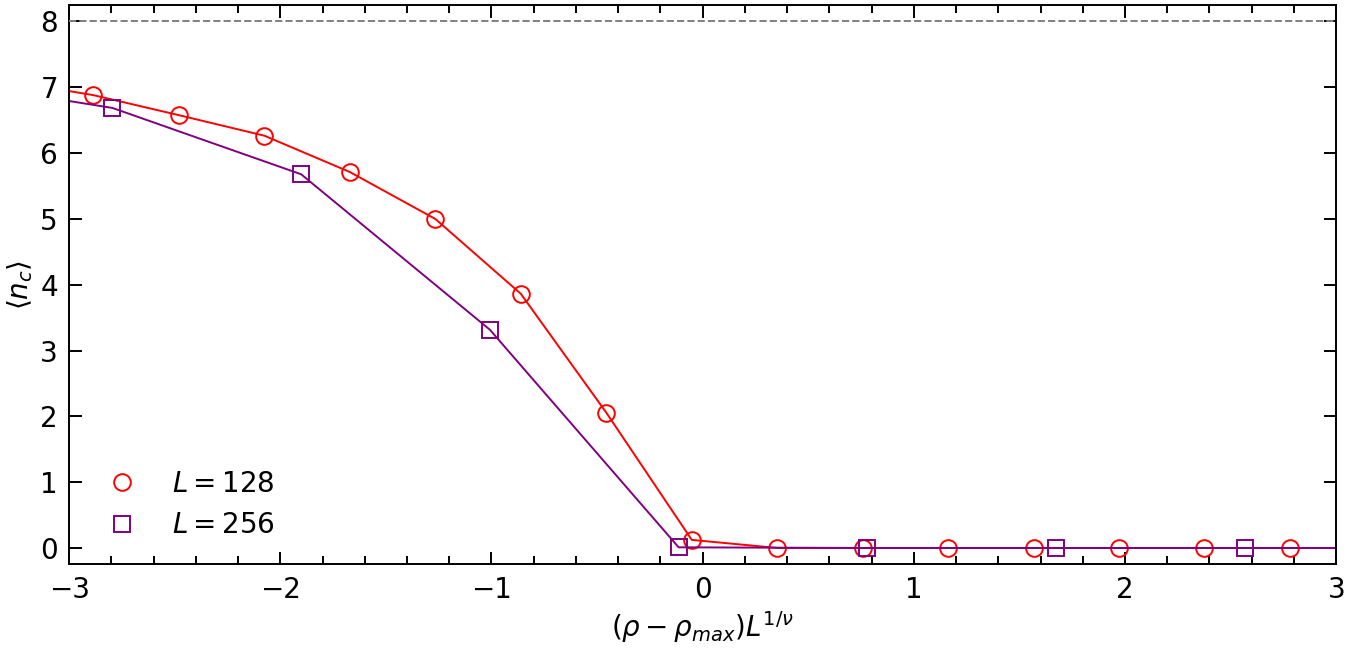

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from matplotlib.lines import Line2D

# Parâmetros do gráfico
p0_filter = 1.0
num_colors_fix = 8          # <<< num_colors fixo
L_values       = [128, 256] # <<< tamanhos a comparar
k_values       = [1.0e-05, 3.0e-06]   # ou: None
rho_max = 0.092
ms = 12
font_tick_size = 20
font_label_size = 20
font_legend_size = 20
colors = ["red", "purple", "green", "blue"]
markers = ["o-", "s-", "d-", "^-"]   # formatos do PLOT (linha + marcador)
mew = 1.4
thickness = 1.4

assert len(L_values) == len(k_values), "L_values e k_values devem ter o mesmo tamanho."

# Criando a figura e o eixo
fig, ax = plt.subplots(figsize=(14, 7))
legend_handles = []

# Loop para os valores de L e k
for idx, (L, kval) in enumerate(zip(L_values, k_values)):
    # Filtrando os dados diretamente com L e k
    df_filtered = df[(df["L"] == L) & (np.isclose(df["k"], kval)) & (df["n_colors"]==num_colors_fix)]

    if df_filtered.empty:
        print(f"[WARN] sem dados para L={L}, k={kval}")
        continue

    fmt = markers[idx % len(markers)]
    color = colors[idx % len(colors)]

    # Reescalando e plotando os dados diretamente do dataframe
    res_scaled = (df_filtered["rho"] - rho_max) * L ** (1 / 0.875)
    line, = ax.plot(res_scaled, df_filtered["n_c"], fmt,
                    color=color, linewidth=thickness,
                    ms=ms, markeredgewidth=mew, zorder=2)

    # Handle da legenda com o mesmo estilo do marcador
    handle = Line2D(
        [0], [0],
        linestyle='None',
        marker=line.get_marker(),
        markersize=ms,
        markeredgewidth=line.get_markeredgewidth(),
        markeredgecolor=line.get_markeredgecolor(),
        markerfacecolor=line.get_markerfacecolor(),      # pode ser 'none' — mantemos
        fillstyle=line.get_fillstyle(),
        alpha=(line.get_alpha() if line.get_alpha() is not None else 1.0),
        color=line.get_color(),
        label=fr"$L = {L}$",
    )
    legend_handles.append(handle)

# Definir os limites e a linha guia
ax.set_xlim([-3, 3])  # Ajuste no limite de X após reescalamento
ax.axhline(y=8, xmin=0.0, xmax=1.0, color='gray', linestyle='--', lw=1.4, zorder=100)

# Definir rótulos e limites no gráfico
ax.set_xlabel(r"$(\rho - \rho_{max})L^{1/\nu}$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, 8.25])

# Definir ticks no eixo X e Y
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_major_locator(MultipleLocator(1.0))

# Ajustar parâmetros dos ticks
ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)

# Aumentar a espessura das bordas do gráfico
for spine in ax.spines.values():
    spine.set_linewidth(thickness)

# Legenda com os handles personalizados
ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="lower left")

# Ajuste final de layout e exibição
plt.tight_layout()
plt.show()
